# Предыдущий блокнот - [graphs.ipynb](https://colab.research.google.com/drive/1mqBJe0TWvfZ4GlYTSd-k6zhD5eQvoqOq?usp=sharing)

# Импорты

In [ ]:
!pip install pyfglt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
import pyfglt.fglt as fg

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Случайные блуждания и word2vec

In [ ]:
import networkx as nx
import numpy as np
G = nx.karate_club_graph()

def next_node(G, previous, current, p, q):
  neighbors = list(G.neighbors(current))
  alphas = []
  for neighbor in neighbors:
    if neighbor == previous: alpha = 1/p # возврат
    elif G.has_edge(neighbor, previous): alpha = 1 # обход в ширину
    else: alpha = 1/q                              # обход в глубину
    alphas.append(alpha)
  probs = [alpha / sum(alphas) for alpha in alphas]
  next = np.random.choice(neighbors, size=1, p=probs)[0]
  return next

def random_walk(G, start, length, p, q):
  walk = [start]
  for i in range(length):
    current = walk[-1]
    previous = walk[-2] if len(walk) > 1 else None
    next = next_node(G, previous, current, p, q)
    walk.append(next)
  return [int(x) for x in walk]

def drawGraphWithWalk(G,walk):
 pos=nx.kamada_kawai_layout(G)
 c,k=[],0
 for u,v in G.edges:
  found=False
  for k in range(len(walk)-1):
   if (walk[k]==u and walk[k+1]==v) or (walk[k]==v and walk[k+1]==u):
    found=True
    break
  if found: c.append('red')
  else: c.append('blue')
 nx.draw(G,pos,with_labels=True,edge_color=c)
 print(walk)

In [ ]:
walks = random_walk(G, 0, 8, p=1000, q=0.0001)

[0, 13, 33, 8, 2, 27, 33, 13, 1]


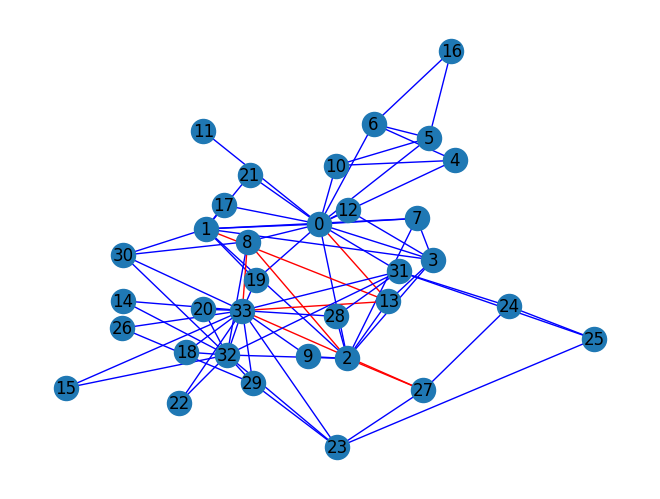

In [ ]:
drawGraphWithWalk(G, walks)

In [ ]:
!pip install gensim

In [ ]:
from gensim.models.word2vec import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
labels = []
for node in G.nodes:
  label = G.nodes[node]['club']
  labels.append(1 if label == 'Officer' else 0)
walks = []

In [ ]:
node2vec = Word2Vec(
  walks,
  hs=1, # Hierarchical softmax
  sg=1, # Skip-gram
  vector_size=100,
  window=10,
  workers=2,
  min_count=1,
  seed=0)

In [ ]:
node2vec.train(walks, total_exmamples=node2vec.corpus_count, epochs=30, report_delay=1)

RuntimeError: you must first build vocabulary before training the model

In [ ]:
train_mask = list(range(0,34,2))
train_mask_str = [str(x) for x in train_mask]
test_mask = list(range(1,34,2))
test_mask_str = [str(x) for x in test_mask]
labels = np.array(labels)

In [ ]:
clf = RandomForestClassifier(random_state=0)
clf.fit(node2vec.wv[train_mask_str], labels[train_mask])
y_pred = clf.predict(node2vec.wv[test_mask_str])
acc = accuracy_score(y_pred, labels[test_mask])

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,5))
# plt.subplots(1,2,1)
# drawGraphWithWalk(G, labels)
# c =
# plt.subplots(1,2,2)
# nx.draw(G,pos,with_labels=True,edge_color=c)

# Прогноз ребра

In [ ]:
!pip install node2vec -q

In [ ]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import pandas as pd
from collections import defaultdict
from node2vec import Node2Vec
import networkx as nx

In [ ]:
url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
zurl=urlopen(url)
zfile=ZipFile(BytesIO(zurl.read()))
zfile.extractall('.')
ratings = pd.read_csv('ml-100k/u.data', sep='\t',names=['user_id', 'movie_id', 'rating', 'unix_timestamp'])
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [ ]:
movies = pd.read_csv('ml-100k/u.item', sep='|',usecols=range(2), names=['movie_id', 'title'],encoding='latin-1')
movies

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [ ]:
ratings = ratings[ratings.rating >= 4]
ratings

,user_id,movie_id,rating,unix_timestamp
5,298,474,4,884182806
7,253,465,5,891628467
11,286,1014,5,879781125
12,200,222,5,876042340
16,122,387,5,879270459
...,...,...,...,...
99988,421,498,4,892241344
99989,495,1091,4,888637503
99990,806,421,4,882388897
99991,676,538,4,892685437


In [ ]:
pairs = defaultdict(int)
for group in ratings.groupby("user_id"):
  user_movies = list(group[1]["movie_id"])
  # for i in range(len(user_movies)):


In [ ]:
for pair in pairs:
  scores.append(pairs[pair])
plt.hist(scores)
print(np.percentile(np.array(scores), 95))

In [ ]:
G = nx.graph()
for pair in pairs:
  movie1, movie2 = pair
  score = pairs[pair]
  if score >= 16:
    G.add_edge(movie1, movie2, weight=score)

In [ ]:
node2vec = Node2Vec(G, dimensions = 64, walk_length = 20, num_walks = 200, p = 2, q = 1, workers = 1)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

In [ ]:
def recommend(movie):
 movie_id = str(movies[movies.title == movie].movie_id.values[0])
 for id in model.wv.most_similar(movie_id)[:5]:
  title = movies[movies.movie_id == int(id[0])].title.values[0]
  print(f'{title}: {id[1]:.2f}')
 return movie_id

# Прогноз графа

## Эмбеддинг по новой вершине, связанной со всеми вершинами в графе

In [ ]:
G = nx.karate_club_graph()
G2 = G.copy()
for node in range(34):
  G2.add_edge(34,node)
node2vec = Node2Vec(G2, dimensions = 5, walk_length = 10, num_walks = 200, p = 2, q = 1, workers = 1)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/35 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:00<00:00, 368.37it/s]


In [ ]:
model.wv[34]

array([ 0.10904791,  0.41070357,  1.0758911 , -0.19039494,  0.10805398],
      dtype=float32)

## Анонимные блуждания

In [ ]:
def next_node(G, previous, current, p, q):
  neighbors = list(G.neighbors(current))
  alphas = []
  for neighbor in neighbors:
    if neighbor == previous: alpha = 1/p # возврат
    elif G.has_edge(neighbor, previous): alpha = 1 # обход в ширину
    else: alpha = 1/q                              # обход в глубину
    alphas.append(alpha)
  probs = [alpha / sum(alphas) for alpha in alphas]
  next = np.random.choice(neighbors, size=1, p=probs)[0]
  return next

def random_anonymous_walk(G, start, length, p, q):
  walk = [0]
  encoder,enc_max={},0
  encoder[start]=0
  for i in range(length):
    current = walk[-1]
    previous = walk[-2] if len(walk) > 1 else None
    next = next_node(G, previous, current, p, q)
    if next not in encoder:
      enc_max+=1
      encoder[next]=enc_max
    walk.append(encoder[next])
  return [int(x) for x in walk],encoder

In [ ]:
walks = []
for node in G.nodes:
  for _ in range(80):
    walk, code = random_anonymous_walk(G,node,2,3,2)
    walk_str = ' '.join([str(x) for x in walk])
    walks.append(walk_str)
print(walks)

['0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 1 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 0', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 0', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 1 2', '0 1 0', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 1 0', '0 1 2', '0 1 2', '0 1 0', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 0 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 1', '0 1 2', '0 0 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 0 1', '0 1 2', '0 1 2', '0 1 2', '0 0 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 1 2', '0 0 1', '0 1 2', '0 1 2', '0 1 2', '0 1 2', 

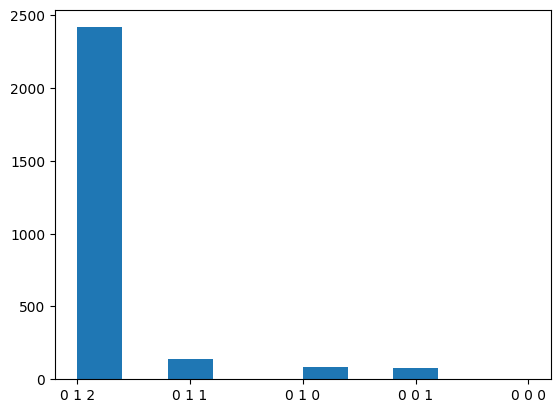

In [ ]:
plt.hist(walks);

In [ ]:
N = 5
P = 0.3
graphs = []
for _ in range(30):
  graphs.append(nx.erdos_renyi_graph(N, P))

for g in graphs:
  for node in g.nodes:
    for _ in range(80):
      walk, code = random_anonymous_walk(G,node,2,3,2)
      walk_str = ' '.join([str(x) for x in walk])
      walks.append(walk_str)


SyntaxError: invalid syntax (ipython-input-626221485.py, line 3)

# Pagerank

In [ ]:
import numpy as np
M = np.array([[0.5, 0.5, 0], [0.5, 0, 0], [0, 0.5, 1]])
Nm = 1/3 * np.ones((3,3))
b = 0.8
G = b*M+(1-b)*Nm
for i in range(10):
  Gold = G.copy()
  G = G@G
  print(f'\nitt: {i}\nres:\n{G}')
  if (np.abs((G-Gold))<1e-10).all():
    break

In [ ]:
G

array([[0.21212121, 0.21212121, 0.21212121],
       [0.15151515, 0.15151515, 0.15151515],
       [0.63636364, 0.63636364, 0.63636364]])

In [ ]:
import networkx as nx
G1 = nx.DiGraph()
for i in range(M.shape[0]):
  for j in range(M.shape[1]):
     G1.add_edge(i,j,weight=M[j,i])
print(G1)

DiGraph with 3 nodes and 9 edges


In [ ]:
A = nx.adjacency_matrix(G1).toarray()
print(A)

[[0.5 0.5 0. ]
 [0.5 0.  0.5]
 [0.  0.  1. ]]


In [ ]:
pr = nx.pagerank(G1, b)
pr

{0: 0.21212254941844777, 1: 0.1515159780102962, 2: 0.636361472571256}

## Рекоммендательные системы. Topic-specific/Personalized PageRank

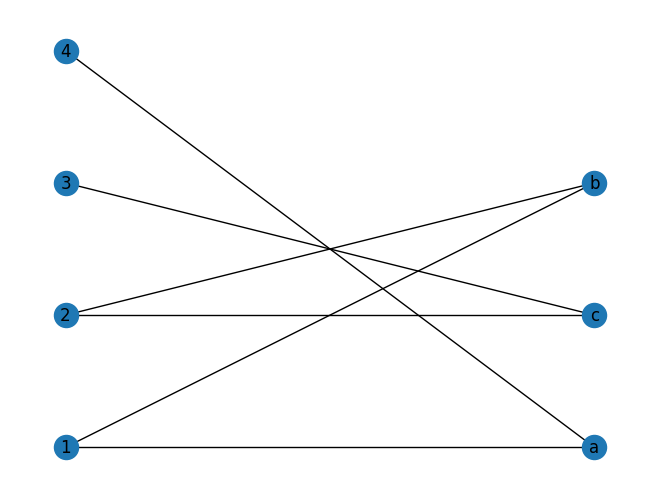

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
B = nx.Graph()
B.add_nodes_from([1,2,3,4], bipartite=0) # Add the node attribute "bipartite"
B.add_nodes_from(['a','b','c'], bipartite=1)
B.add_edges_from([(1,'a'), (1,'b'), (2,'b'), (2,'c'), (3,'c'), (4,'a')])

l, r = nx.bipartite.sets(B)
pos = {}

pos.update(((node, (1, index)) for index, node in enumerate(l)))
pos.update(((node, (2, index)) for index, node in enumerate(r)))

nx.draw(B, pos=pos, with_labels=True);

## Неотрицательные матричные разложения

### Разложение по Холецкому

In [ ]:
A = np.array([[1,1,0.1],[1,2,1],[0.1,1,2]])
B = np.linalg.cholesky(A)
print(B, B@B.T)

[[1.         0.         0.        ]
 [1.         1.         0.        ]
 [0.1        0.9        1.08627805]] [[1.  1.  0.1]
 [1.  2.  1. ]
 [0.1 1.  2. ]]


### Неотрицательная матричная факторизация

$A = W^TH$

In [ ]:
from sklearn.decomposition import NMF
A = np.array([[0.1,1,0.1],[1,2,1],[0.1,1,2]])
model = NMF(n_components=2, init='random', random_state=0)
W = model.fit_transform(A)
HT = model.components_
B = W

In [ ]:
print('A:\n',A)
print('B:\n',B)
print('B @ B.T:\n',B @ B.T)
print('W @ HT:\n',W @ HT)

A:
 [[0.1 1.  0.1]
 [1.  2.  1. ]
 [0.1 1.  2. ]]
B:
 [[0.38039978 0.05454056]
 [0.78369285 0.3921988 ]
 [0.02451204 0.83788218]]
B @ B.T:
 [[0.14767867 0.31950733 0.05502294]
 [0.31950733 0.76799439 0.3478263 ]
 [0.05502294 0.3478263  0.70264739]]
W @ HT:
 [[0.3950859  0.85529931 0.1485116 ]
 [0.85523368 2.07098877 0.97620068]
 [0.14855459 0.97619038 2.00798229]]


### Решение через собственные значения и векторы

Недостатки:
- Слишком простая схема, не учитывается информация помимо топологической

In [ ]:
from scipy.linalg import eigh

eigenvalues, eigenvectors = eigh(A)
eigenvalues = np.maximum(eigenvalues,0)
sqrt_eigenvalues = np.sqrt(eigenvalues)
B = eigenvectors @ np.diag(sqrt_eigenvalues)

In [ ]:
print('A:\n',A)
print('B:\n',np.round(B,2))
print('B @ B.T:\n',B @ B.T)

A:
 [[0.1 1.  0.1]
 [1.  2.  1. ]
 [0.1 1.  2. ]]
B:
 [[ 0.   -0.43 -0.46]
 [ 0.   -0.59 -1.31]
 [ 0.    0.86 -1.13]]
B @ B.T:
 [[0.39507846 0.85526229 0.14853711]
 [0.85526229 2.07099469 0.97619226]
 [0.14853711 0.97619226 2.00798381]]


# Классификация вершин и передача сообщений

Homophily - похожие организмы тянутся друг к другу

Influence - организмы меняются под действием социальной группы

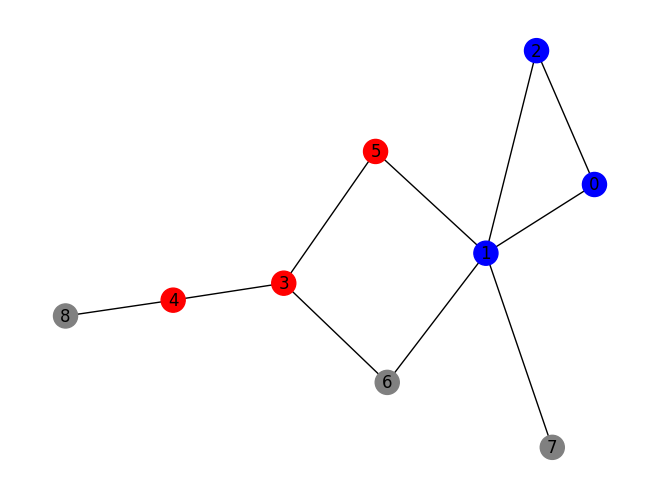

In [ ]:
G=nx.Graph()
G.add_nodes_from([(0,{'Y':1,'train':1}),(1,{'Y':1,'train':1}),(2,{'Y':1,'train':1}),
                  (3,{'Y':0,'train':1}),(4,{'Y':0,'train':1}),(5,{'Y':0,'train':1}),
                  (6,{'Y':-1,'train':0}),(7,{'Y':-1,'train':0}),(8,{'Y':-1,'train':0}),
                  ])
G.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(3,6),(1,5),(1,6),(1,7),(4,8)])
cols={-1:'gray',0:'red',1:'blue'}
c = []
for node,attr in G.nodes.items():
    c.append(cols[attr['Y']])
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, node_color=c, with_labels=True)

## Связный классификатор

Проблемы:
- не гарантируется конферсия

In [ ]:
import random as rd
for node in G.nodes():
  if G.nodes[node]['train']==0: G.nodes[node]['Y']=0.5
for _ in range(1000):
  n=rd.choice(list(G.nodes()))
  w=[]
  for n_n in G.neighbors(n): w.append(G.nodes[n_n]['Y'])
  w=np.array(w)
  if G.nodes[n]['train']==0: G.nodes[n]['Y']=w.mean()
c = []
for node,attr in G.nodes.items():
  c.append(cols[attr['Y']])

{'Y': 1, 'train': 1, 'F': 0}


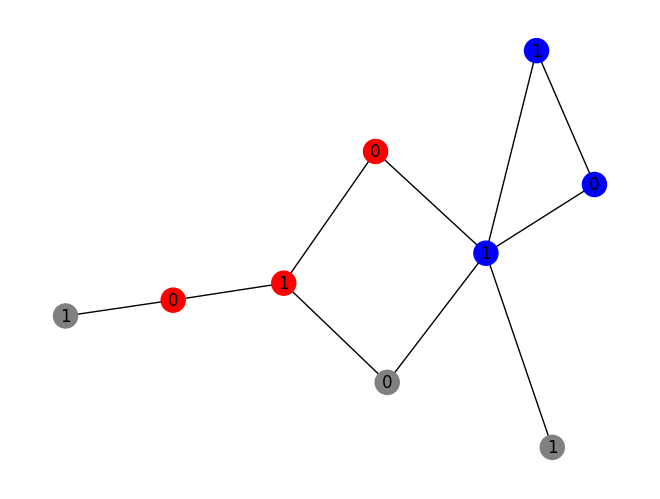

In [ ]:
G=nx.Graph()
G.add_nodes_from([(0,{'Y':1,'train':1,'F':0}),(1,{'Y':1,'train':1,'F':1}),(2,{'Y':1,'train':1,'F':1}),
                  (3,{'Y':0,'train':1,'F':1}),(4,{'Y':0,'train':1,'F':0}),(5,{'Y':0,'train':1,'F':0}),
                  (6,{'Y':-1,'train':0,'F':0}),(7,{'Y':-1,'train':0,'F':1}),(8,{'Y':-1,'train':0,'F':1}),
                  ])
G.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(3,6),(1,5),(1,6),(1,7),(4,8)])
cols={-1:'gray',0:'red',1:'blue'}
c = []
for node,attr in G.nodes.items():
    c.append(cols[attr['Y']])

labeldict = {}
for node, attr in G.nodes.items():
  labeldict[node] = attr['F']

pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, node_color=c, labels=labeldict, with_labels=True)

In [ ]:
import numpy as np
### Train F1
x1,y1=[],[]
for n in G.nodes():
  if G.nodes[n]['train']==1:
    x1.append(G.nodes[n]['F'])
    y1.append(G.nodes[n]['Y'])
print(x1,y1)
x1=np.array(x1)[:,np.newaxis]
y1=np.array(y1)

[0, 1, 1, 1, 0, 0] [1, 1, 1, 0, 0, 0]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
def f1(x1,y1):
 clf=DecisionTreeClassifier(max_depth=1)
 clf.fit(x1,y1)
 return clf
clf1=f1(x1,y1)

In [ ]:
### train F2
### summary: mean labels
x2,y2=[],[]
nsel=[1]*6+[0]*3
for n in G.nodes():
    zacc=[]
    for n_n in G.neighbors(n):
     if nsel[n_n]==1:
       if G.nodes[n_n]['train']==1:
        zacc.append(G.nodes[n_n]['Y'])
       else:
        zacc.append(int(clf1.predict([[G.nodes[n_n]['F']]])[0]))
    zm=np.array(zacc)
    G.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))

In [ ]:
for n in G.nodes():
 if nsel[n]==1:
    x2.append([G.nodes[n]['F2']])
    if(G.nodes[n]['train']==1):
     y2.append(G.nodes[n]['Y'])
    else:
     y2.append(clf1.predict([[G.nodes[n]['F']]])[0])

x2, y2 = np.array(x2), np.array(y2)

In [ ]:
clf2=f1(x2,y2)
clf2.score(x2,y2)

1.0

In [ ]:
G1=G.copy()
for itt in range(1000):
 for n in G1.nodes():
    if G1.nodes[n]['train']!=1:
      G1.nodes[n]['Y']=int(clf1.predict([[G1.nodes[n]['F']]])[0])
 for n in G1.nodes():
    zacc=[]
    for n_n in G1.neighbors(n):
        zacc.append(G1.nodes[n_n]['Y'])
    zm=np.array(zacc)
    G1.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))

In [ ]:
c = []
for node,attr in G1.nodes.items():
  c.append(cols[attr['Y']])

labeldict = {}
for node, attr in G1.nodes.items():
  labeldict[node] = attr['F2']

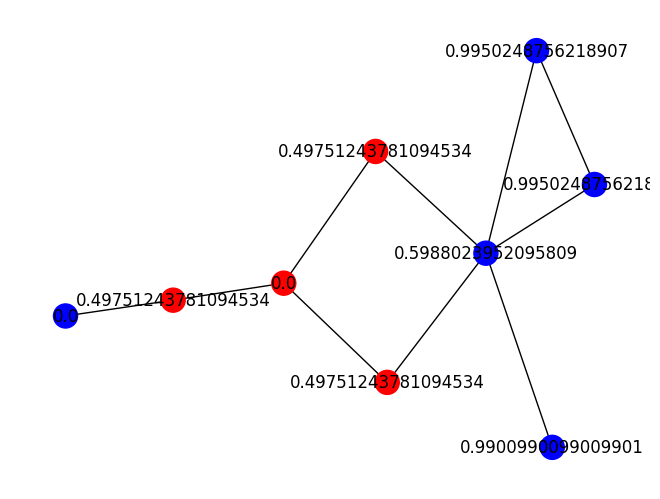

In [ ]:
nx.draw(G1, pos, node_color=c, labels=labeldict, with_labels=True)

## Распространение доверия

Основа алгоритма:
1. Вершина получает состояние о себе с точки зрения соседей в виде матриц вероятностей
2. Соседям передаётся информация о себе с точки зрения других соседей: перемножаются все матрицы за исключением матрицы получателя

Проблемы:
- Циклы - не зная можно получить свою же информацию

## Correct & Smooth

1. Из идеальных значений вычитаются выданные классифиактором метки
2. Матрицы смежностей нод умножаем на соответствующие им фичи и на диагональную матрицу степеней вершин-> получатся значения для добавления
$A^{̃} 𝝣 D^{-1/2}AD^{-1/2}$
3. Матрицы распространяются между соседями

# Графовые нейронные сети

- энкодер получает сеть и преобразует в некоторый эмбеддинг
- эмбеддинги передаются на функцию декодера

V - nodes\
A - adjacency matrix - к матрице смежности стоит добавлять единичную\
D - degree matrix\
v - node in V

Максимальный размер графовой сети - диаметр графа (максимальный путь между двумя точками графра)

3 слоя достаточно для графов реальной жизни, чаще всего используется 2-слойная сеть

Работают по схеме - сначала передача сообщений, потом агрегация:

- Выполняются групповые операции и записываются в фичи ноды
- Фичи с помощью нейронов комбинируются, количество фич изменяется

На выходе слоая свёртки тот же граф, но с новыми фичами, постепенно области начинают пересекаться



In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

D = np.array([
[3, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 2, 0],
[0, 0, 0, 2]
])
print(D)

D_inv = np.linalg.inv(D)
print(D_inv)

D_invl = np.linalg.inv(D+ np.identity(4))
print(D_invl)

A = np.array([
    [1, 1, 1, 1],
    [1, 1, 0, 0],
    [1, 0, 1, 1],
    [1, 0, 0, 1],
])

print(D_invl @ A)
print(A @ D_invl)

[[3 0 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 2]]
[[0.33333333 0.         0.         0.        ]
 [0.         1.         0.         0.        ]
 [0.         0.         0.5        0.        ]
 [0.         0.         0.         0.5       ]]
[[0.25       0.         0.         0.        ]
 [0.         0.5        0.         0.        ]
 [0.         0.         0.33333333 0.        ]
 [0.         0.         0.         0.33333333]]
[[0.25       0.25       0.25       0.25      ]
 [0.5        0.5        0.         0.        ]
 [0.33333333 0.         0.33333333 0.33333333]
 [0.33333333 0.         0.         0.33333333]]
[[0.25       0.5        0.33333333 0.33333333]
 [0.25       0.5        0.         0.        ]
 [0.25       0.         0.33333333 0.33333333]
 [0.25       0.         0.         0.33333333]]


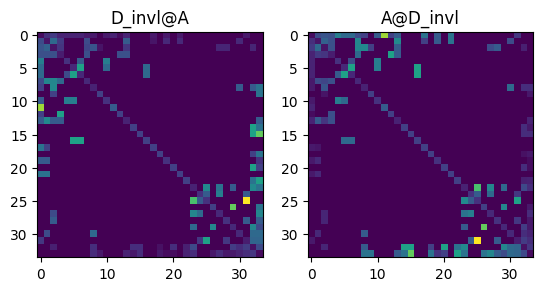

In [ ]:
G = nx.karate_club_graph()
A = nx.adjacency_matrix(G).toarray()
A = A + np.identity(34)
D = np.zeros(A.shape)
d = G.degree()
for i,v in d:
  D[i,i] = v
D_invl = np.linalg.inv(D + np.identity(34))
plt.subplot(121)
plt.title('D_invl@A')
plt.imshow(D_invl@A)
plt.subplot(122)
plt.title('A@D_invl')
plt.imshow(A@D_invl)

In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


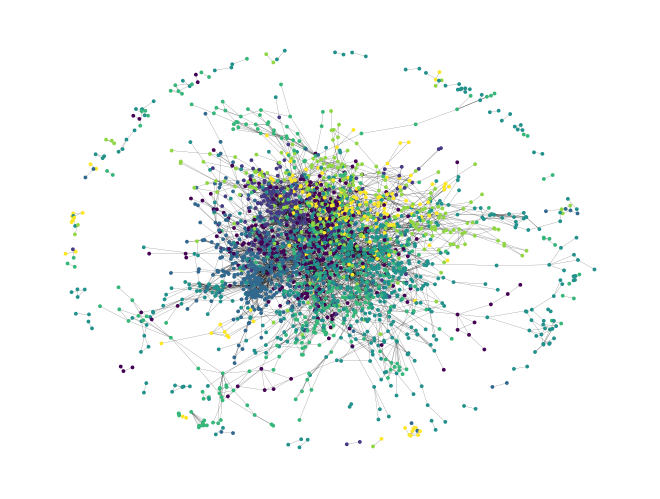

In [ ]:
import torch_geometric
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

dataset = Planetoid(root=".", name="Cora")
data = dataset[0]
true_labels = data.y.cpu().numpy()
g = torch_geometric.utils.to_networkx(data, to_undirected=True)
nx.draw(g,node_size=3,width=0.1,node_color=true_labels)

In [ ]:
data.x.shape

torch.Size([2708, 1433])

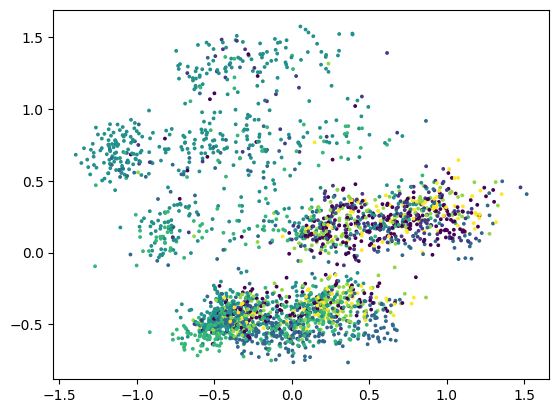

In [ ]:
from sklearn.decomposition import PCA
tr = PCA(n_components=2)
x1 = tr.fit_transform(data.x)
plt.scatter(x1[:,0],x1[:,1],c=data.y,s=3);

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
Xtr, Xt, Ytr, Yt = train_test_split(data.x, data.y)
clf = DecisionTreeClassifier()
clf.fit(Xtr, Ytr)
clf.score(Xt, Yt)

0.6410635155096012

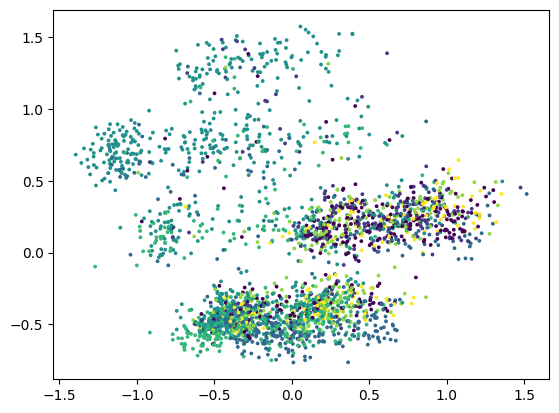

In [ ]:
c = clf.predict(data.x)
plt.scatter(x1[:,0],x1[:,1],c=c,s=3);

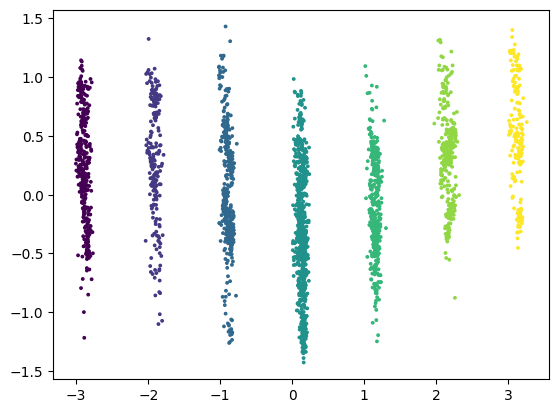

In [ ]:
tr = PCA(n_components=2)
x4 = tr.fit_transform(np.concatenate([data.x, data.y[:,np.newaxis]], axis=-1))
plt.scatter(x4[:,0],x4[:,1],c=data.y,s=3);

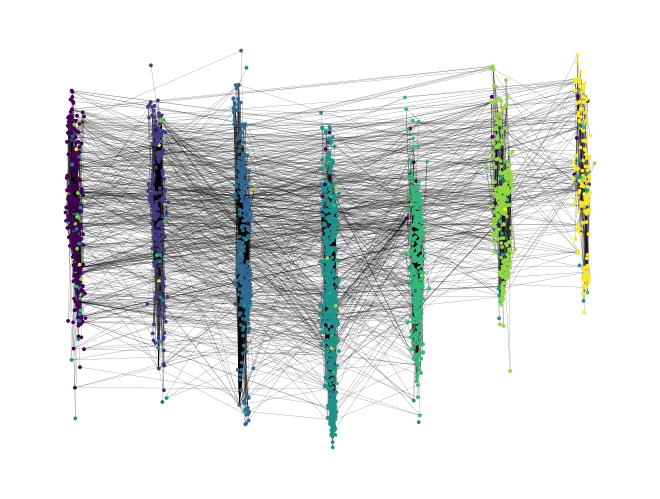

In [ ]:
nx.draw(g,pos=x4,node_size=3,width=0.1,node_color=c)

In [ ]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

def accuracy(pred_y, y):
  return ((pred_y == y).sum() / len(y)).item()

class GCN(torch.nn.Module):
  def __init__(self, dim_in, dim_h, dim_out):
    super().__init__()
    self.gcn1 = GCNConv(dim_in, dim_h)
    self.gcn2 = GCNConv(dim_h, dim_out)

  def forward(self, x, edge_index):
    h = self.gcn1(x, edge_index)
    h = torch.relu(h)
    h = self.gcn2(h, edge_index)
    return F.log_softmax(h, dim=1)

  def fit(self, data, epochs):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(),lr=0.01,weight_decay=5e-4)
    self.train()
    for epoch in range(epochs+1):
      optimizer.zero_grad()
      out = self.forward(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
      loss.backward()
      optimizer.step()
      if(epoch % 20 == 0):
        val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
        val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
        print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

  @torch.no_grad()
  def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    acc = accuracy(out.argmax(dim=1)[data.test_mask],
    data.y[data.test_mask])
    return acc

In [ ]:
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

GCN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 7)
)


In [ ]:
gcn.fit(data, epochs=100)

Epoch   0 | Train Loss: 1.943 | Train Acc: 17.86% | Val Loss: 1.96 | Val Acc: 12.00%
Epoch  20 | Train Loss: 0.100 | Train Acc: 100.00% | Val Loss: 0.76 | Val Acc: 77.20%
Epoch  40 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.74 | Val Acc: 76.80%
Epoch  60 | Train Loss: 0.015 | Train Acc: 100.00% | Val Loss: 0.72 | Val Acc: 76.20%
Epoch  80 | Train Loss: 0.018 | Train Acc: 100.00% | Val Loss: 0.72 | Val Acc: 76.20%
Epoch 100 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.72 | Val Acc: 75.80%


In [ ]:
yp = gcn(data.x,data.edge_index)[data.test_mask]

In [ ]:
accuracy(yp.argmax(axis=-1), data.y[data.test_mask])

0.7900000214576721

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(data.y[data.test_mask], yp.argmax(axis=-1)))

              precision    recall  f1-score   support

           0       0.68      0.73      0.71       130
           1       0.72      0.87      0.79        91
           2       0.85      0.86      0.86       144
           3       0.90      0.74      0.81       319
           4       0.78      0.83      0.81       149
           5       0.78      0.76      0.77       103
           6       0.65      0.86      0.74        64

    accuracy                           0.79      1000
   macro avg       0.77      0.81      0.78      1000
weighted avg       0.80      0.79      0.79      1000



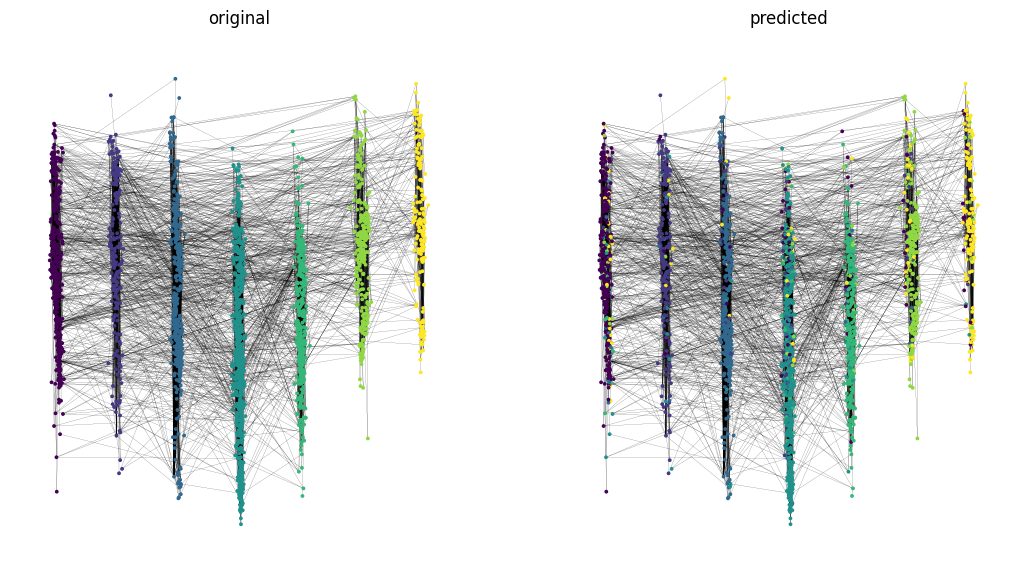

In [ ]:
plt.figure(figsize=(13,7))
plt.subplot(121)
plt.title('original')
nx.draw(g,pos=x4,node_size=3,width=0.1,node_color=data.y)
plt.subplot(122)
plt.title('predicted')
nx.draw(g,pos=x4,node_size=3,width=0.1,node_color=gcn(data.x,data.edge_index).argmax(axis=-1))

In [ ]:
from torch.nn import Conv1d

class GCN(torch.nn.Module):
  def __init__(self, dim_in, dim_h, dim_out, layers=3):
    super().__init__()
    self.gcn1 = GCNConv(dim_in, dim_in)
    self.gcnA = GCNConv(dim_in, dim_in)
    self.gcn2 = GCNConv(dim_in, dim_out)

  def forward(self, x, edge_index):
    h_old=x
    h = self.gcn1(x, edge_index)
    h = torch.relu(h)+h_old
    h_old=h
    h = self.gcnA(h, edge_index)
    h = torch.relu(h)+h_old
    h_old=h
    h = self.gcn2(h, edge_index)
    return F.log_softmax(h, dim=1)

  def fit(self, data, epochs):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(),lr=0.01,weight_decay=5e-4)
    self.train()
    for epoch in range(epochs+1):
      optimizer.zero_grad()
      out = self.forward(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
      loss.backward()
      optimizer.step()
      if(epoch % 20 == 0):
        val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
        val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
        print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

  @torch.no_grad()
  def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    acc = accuracy(out.argmax(dim=1)[data.test_mask],
    data.y[data.test_mask])
    return acc

In [ ]:
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

GCN(
  (gcn1): GCNConv(1433, 1433)
  (gcnA): GCNConv(1433, 1433)
  (gcn2): GCNConv(1433, 7)
)


In [ ]:
gcn.fit(data, epochs=100)

Epoch   0 | Train Loss: 1.973 | Train Acc: 14.29% | Val Loss: 1.95 | Val Acc: 11.80%
Epoch  20 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 1.00 | Val Acc: 75.40%
Epoch  40 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 0.87 | Val Acc: 75.40%
Epoch  60 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 0.81 | Val Acc: 75.20%
Epoch  80 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 0.80 | Val Acc: 76.80%
Epoch 100 | Train Loss: 0.054 | Train Acc: 97.86% | Val Loss: 0.95 | Val Acc: 76.80%


In [ ]:
accuracy(yp.argmax(axis=-1), data.y[data.test_mask])

0.7900000214576721

In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.4 MB/s eta 0:00:00


In [ ]:
from torch_geometric.datasets import WikipediaNetwork
import torch_geometric.transforms as T
dataset = WikipediaNetwork(root=".", name="chameleon", \
   transform = T.RandomNodeSplit(num_val=200, num_test=500))
data = dataset[0]
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of unique features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Processing...


Dataset: WikipediaNetwork()
-------------------
Number of graphs: 1
Number of nodes: 2277
Number of unique features: 2325
Number of classes: 5


Done!


In [ ]:
!wget -c https://snap.stanford.edu/data/wikipedia.zip
!unzip wikipedia.zip

--2025-10-24 03:38:00--  https://snap.stanford.edu/data/wikipedia.zip
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3784155 (3.6M) [application/zip]
Saving to: ‘wikipedia.zip’

wikipedia.zip       100%[===================>]   3.61M  1.01MB/s    in 3.9s    

2025-10-24 03:38:05 (943 KB/s) - ‘wikipedia.zip’ saved [3784155/3784155]

Archive:  wikipedia.zip
   creating: wikipedia/
   creating: wikipedia/chameleon/
  inflating: wikipedia/chameleon/musae_chameleon_edges.csv  
  inflating: wikipedia/chameleon/musae_chameleon_features.json  
  inflating: wikipedia/chameleon/musae_chameleon_target.csv  
   creating: wikipedia/crocodile/
  inflating: wikipedia/crocodile/musae_crocodile_edges.csv  
  inflating: wikipedia/crocodile/musae_crocodile_features.json  
  inflating: wikipedia/crocodile/musae_crocodile_target.csv  
   creating: wikipe

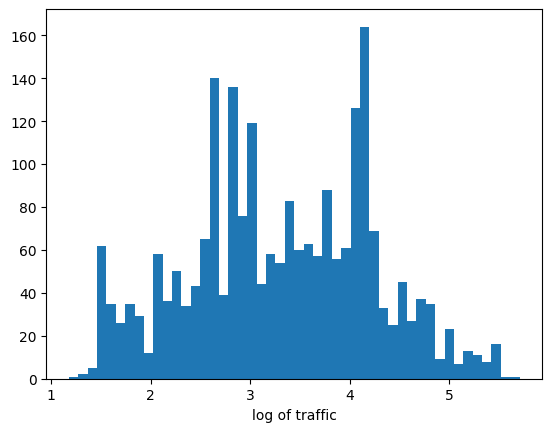

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

df = pd.read_csv('wikipedia/chameleon/musae_chameleon_target.csv')
values = np.log10(df['target'])
data.y = torch.tensor(values)
plt.hist(values,bins=int(np.round(np.sqrt(values.shape[0]))))
plt.xlabel('log of traffic');

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Conv1d

class GCN(torch.nn.Module):
  def __init__(self, dim_in, dim_h, dim_out, layers=3):
    super().__init__()
    self.gcn1 = GCNConv(dim_in, dim_h*4)
    self.gcn2 = GCNConv(dim_h*4, dim_h*2)
    self.gcn3 = GCNConv(dim_h*2, dim_h)
    self.linear = torch.nn.Linear(dim_h, dim_out)

  def forward(self, x, edge_index):
#    print('x:',x.shape)
    h = self.gcn1(x, edge_index)
    h = torch.selu(h)
    h = F.dropout(h, p=0.2, training=self.training)
    h = self.gcn2(h, edge_index)
    h = torch.selu(h)
    h = F.dropout(h, p=0.2, training=self.training)
    h = self.gcn3(h, edge_index)
    h = torch.selu(h)
    h = self.linear(h)
#    print('h:',h.shape)
    return h

  def fit(self, data, epochs):
    optimizer = torch.optim.Adam(self.parameters(),lr=0.02,weight_decay=5e-4)
    self.train()
    for epoch in range(epochs+1):
      optimizer.zero_grad()
      out = self.forward(data.x, data.edge_index)
      loss = F.mse_loss(out.squeeze()[data.train_mask], data.y[data.train_mask].float())
      loss.backward()
      optimizer.step()
      if(epoch % 20 == 0):
        val_loss = F.l1_loss(out.squeeze()[data.val_mask], data.y[data.val_mask])
        print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Val Loss: {val_loss:.2f}')

  @torch.no_grad()
  def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    return F.l1_loss(out.squeeze()[data.test_mask],data.y[data.test_mask].float())

In [ ]:
gcn = GCN(dataset.num_features, 128, 1)
print(gcn)
gcn.to('cuda')
data.to('cuda')
gcn.fit(data, epochs=200)
gcn.to('cpu')
data.to('cpu')
loss = gcn.test(data)
print(f'GCN test loss: {loss:.5f}')

GCN(
  (gcn1): GCNConv(2325, 512)
  (gcn2): GCNConv(512, 256)
  (gcn3): GCNConv(256, 128)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)
Epoch   0 | Train Loss: 10.802 | Val Loss: 3.18
Epoch  20 | Train Loss: 53.112 | Val Loss: 4.95
Epoch  40 | Train Loss: 19.973 | Val Loss: 3.48
Epoch  60 | Train Loss: 10.952 | Val Loss: 2.75
Epoch  80 | Train Loss: 4.459 | Val Loss: 1.56
Epoch 100 | Train Loss: 3.269 | Val Loss: 1.41
Epoch 120 | Train Loss: 2.153 | Val Loss: 1.16
Epoch 140 | Train Loss: 1.831 | Val Loss: 1.17
Epoch 160 | Train Loss: 1.747 | Val Loss: 1.04
Epoch 180 | Train Loss: 1.158 | Val Loss: 0.86
Epoch 200 | Train Loss: 1.097 | Val Loss: 0.85
GCN test loss: 0.87701
